# RGP — Rigorous Gradation Pruning

Implements RGP (structured pruning with DFOT scoring and fine-tuning recovery) on ResNet50.
Designed to be run from `master.ipynb` which handles data/model loading.
Can also be run standalone by running all cells top to bottom.


In [1]:
import os, copy
import torch

# navigate to project root first — must happen before module imports
target = "CS6423_knowledge_distillation_project"
if not os.getcwd().endswith(target):
    import sys
    os.chdir(os.path.join(os.getcwd(), target))
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

print(f'Working dir: {os.getcwd()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# now safe to import modules
import torch.nn as nn
import pandas as pd
from modules.model_trainer import modelTrainer
from modules.evaluate_model import ModelEvaluator


Working dir: /home/kod6/CS6423_knowledge_distillation_project
Device: cuda


In [2]:
from modules.dataset_prepper import datasetPrepper

data_prep = datasetPrepper(
    dataframe_path='data/labels.csv',
    image_dir='data/test_images',
).prepare(compute_class_weights=True)

CLASS_NAMES = data_prep.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {NUM_CLASSES}')
print(f'Train batches: {len(data_prep.train_loader)} | Val batches: {len(data_prep.val_loader)}')


Classes: 61
Train batches: 249 | Val batches: 50


In [3]:
from modules.imagenet_loader import ImagenetLoader

WEIGHTS_PATH = 'trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth'

loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    weights_path=WEIGHTS_PATH,
    load_type='load'
)
loader.freeze_backbone()
resnet50 = resnet50.to(device)

print(f'ResNet50 loaded — {sum(p.numel() for p in resnet50.parameters()):,} params')


ResNet50 loaded — 23,633,021 params


In [4]:
evaluator = ModelEvaluator(
    data_loader=data_prep.val_loader,
    class_names=CLASS_NAMES,
    device=str(device)
)
baseline_metrics = evaluator.evaluate_single(resnet50, model_name='ResNet50_baseline')
BASELINE_F1 = baseline_metrics['f1_macro']

print(f'Baseline F1 macro:  {baseline_metrics["f1_macro"]:.4f}')
print(f'Baseline latency:   {baseline_metrics["avg_latency_ms"]:.2f} ms/sample')
print(f'Baseline size:      {baseline_metrics["model_size_mb"]:.2f} MB')



Warming up ResNet50_baseline...
Running inference...
Baseline F1 macro:  0.4867
Baseline latency:   1.14 ms/sample
Baseline size:      90.36 MB


In [5]:
import pandas as pd

# stub for standalone running — in master.ipynb these are defined in Cell 6
if 'results_df' not in dir():
    results_df = pd.DataFrame(columns=['Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'])
    def add_experiment(method, base_model, base_size, compressed_size, f1):
        global results_df
        size_reduction = round(((base_size - compressed_size) / base_size) * 100, 2)
        results_df = pd.concat([results_df, pd.DataFrame([{
            'Method': method,
            'Base_Model': base_model,
            'Size_Reduction_Pct': size_reduction,
            'F1_Score': f1
        }])], ignore_index=True)

# Kellie - RGP: Rigorous Gradient-based Pruning
#
# RGP iteratively removes the least important convolutional filters from ResNet50
# using gradient-based importance scores, shrinking the model in 5 steps from 10%
# to 50% sparsity. After each pruning step the model is fine-tuned to recover
# accuracy, trading off model size against F1 score across 5 Pareto front points.
#
# The process repeats 5 times, each time:
#   A. SCORE   - run a few training batches to measure which filters contribute
#                least to the loss using a gradient-based importance score (DFOT)
#   B. PRUNE   - permanently remove the lowest-scoring 10% of eligible filters,
#                also updating the next layer's input channels to match
#   C. RECOVER - fine-tune the pruned model for 10 epochs to regain accuracy
#
# After each iteration we log F1 and size reduction to the shared results_df,
# giving 5 data points on the Pareto front (10%, 20%, 30%, 40%, 50% sparsity).
#
# Two layer types are always protected from pruning:
#   - conv3 layers (the final 1x1 conv in each ResNet bottleneck block)
#   - downsample layers (the skip connection projections)
#   - stem conv1 (the very first layer - its skip connections are too complex to patch)
# These are skip-connected, meaning pruning their output channels would break the
# residual addition that ResNet depends on.

import copy
import torch.nn as nn
from modules.model_trainer import modelTrainer

# --- 1. DFOT SCORER ---
# Computes a gradient-based importance score for each filter.
# For each filter, it multiplies the weight by its gradient and takes the
# magnitude - filters that have large gradients on large weights are important.
# Alpha=0.5 softens (desensitizes) the scores so pruning isn't too aggressive.

class DFOTScorer:
    def __init__(self, model, alpha=0.5):
        self.model, self.alpha = model, alpha
        self._hooks, self._bufs, self._counts = [], {}, {}

    def register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                h = module.weight.register_hook(self._make_hook(name, module))
                self._hooks.append(h); self._bufs[name] = None; self._counts[name] = 0

    def _make_hook(self, name, module):
        def hook(grad):
            with torch.no_grad():
                raw = (module.weight.detach() * grad).abs().pow(self.alpha)
                f_scores = raw.view(raw.shape[0], -1).sum(dim=1)
                if self._bufs[name] is None: self._bufs[name] = f_scores.clone()
                else: self._bufs[name] += f_scores
                self._counts[name] += 1
        return hook

    def get_scores(self):
        return {n: (b / max(self._counts[n], 1)) for n, b in self._bufs.items() if b is not None}

    def remove_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks = []


# --- 2. FILTER SELECTION ---
# Ranks all eligible filters across all eligible layers by their DFOT score
# and selects the bottom prune_ratio fraction for removal.
# Tracks previously pruned filters in pruning_mask so we never try to prune
# a filter that has already been removed in a previous iteration.

def get_filters_to_prune(scores, prune_ratio, protected_layers, pruning_mask):
    all_entries = []
    for layer_name, filter_scores in scores.items():
        if any(x in layer_name for x in ["conv3", "downsample"]) or layer_name in protected_layers:
            continue
        already_pruned = pruning_mask.get(layer_name, [])
        for f_idx, score in enumerate(filter_scores.cpu().tolist()):
            if f_idx not in already_pruned:
                all_entries.append((score, layer_name, f_idx))
    all_entries.sort(key=lambda x: x[0])
    n_prune = int(len(all_entries) * prune_ratio)
    prune_map = {}
    for _, layer_name, f_idx in all_entries[:n_prune]:
        prune_map.setdefault(layer_name, []).append(f_idx)
    return prune_map


# --- 3. STRUCTURED PRUNING ---
# Actually removes the selected filters from the model by rebuilding each
# affected Conv2d with fewer output channels. Also updates:
#   - The corresponding BatchNorm layer (must match conv output channels)
#   - The NEXT layer's input channels (must match conv output channels)
# This is what makes it "structured" - the model architecture changes and
# the weight tensors get physically smaller, giving real speedup and size reduction.

def structured_prune(model, prune_map):

    def set_module(model, name, new_module):
        parts = name.split(".")
        parent = model
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], new_module)

    def get_module(model, name):
        m = model
        for p in name.split("."): m = getattr(m, p)
        return m

    def prune_conv_out(conv, keep):
        new = nn.Conv2d(conv.in_channels, len(keep), conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[keep])
            if conv.bias is not None: new.bias.copy_(conv.bias[keep])
        return new

    def prune_conv_in(conv, keep):
        new = nn.Conv2d(len(keep), conv.out_channels, conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[:, keep, :, :])
            if conv.bias is not None: new.bias.copy_(conv.bias)
        return new

    def prune_bn(bn, keep):
        new = nn.BatchNorm2d(len(keep))
        with torch.no_grad():
            new.weight.copy_(bn.weight[keep])
            new.bias.copy_(bn.bias[keep])
            new.running_mean.copy_(bn.running_mean[keep])
            new.running_var.copy_(bn.running_var[keep])
        return new

    for layer_name, prune_indices in prune_map.items():
        # skip ResNet skip-connection layers - pruning these breaks residual addition
        if "conv3" in layer_name or "downsample" in layer_name:
            continue

        # skip stem conv1 - feeds into layer1 skip connections, too complex to patch
        if layer_name == "conv1":
            print(f"  Skipping stem conv1 — protected")
            continue

        try:
            conv = get_module(model, layer_name)
        except AttributeError:
            continue
        if not isinstance(conv, nn.Conv2d):
            continue

        keep = [i for i in range(conv.out_channels) if i not in prune_indices]
        if not keep:
            continue

        set_module(model, layer_name, prune_conv_out(conv, keep))

        # update BatchNorm to match new number of output channels
        bn_name = layer_name.replace("conv1", "bn1") if "conv1" in layer_name else \
                  layer_name.replace("conv2", "bn2") if "conv2" in layer_name else None
        if bn_name:
            try:
                bn = get_module(model, bn_name)
                if isinstance(bn, nn.BatchNorm2d):
                    set_module(model, bn_name, prune_bn(bn, keep))
            except AttributeError:
                pass

        # update the next conv layer's input channels to match
        parts = layer_name.split(".")
        if len(parts) == 3:
            layer_group, block_idx, conv_num = parts
            next_name = f"{layer_group}.{block_idx}.conv2" if conv_num == "conv1" else \
                        f"{layer_group}.{block_idx}.conv3" if conv_num == "conv2" else None
            if next_name:
                try:
                    next_conv = get_module(model, next_name)
                    if isinstance(next_conv, nn.Conv2d):
                        set_module(model, next_name, prune_conv_in(next_conv, keep))
                except AttributeError:
                    pass

        pruning_mask[layer_name] = prune_indices

    total = sum(len(v) for v in pruning_mask.values())
    print(f"  Total filters removed: {total}")
    return model


# --- 4. MAIN EXECUTION LOOP ---
# deepcopy so we never modify the original resnet50 baseline
# re-enable gradients since resnet50 was frozen in the loading cell

rgp_model = copy.deepcopy(resnet50).to(device)
for p in rgp_model.parameters():
    p.requires_grad = True

initial_params = sum(p.numel() for p in rgp_model.parameters())
criterion      = nn.CrossEntropyLoss(weight=data_prep.class_weights.to(device))
pruning_mask   = {}
rgp_step_metrics = []

for target in [0.10, 0.20, 0.30, 0.40, 0.50]:
    print(f"\n--- RGP Iteration: {target*100:.0f}% Sparsity ---")

    # A. SCORE - run 15 batches to accumulate gradient-based filter importance scores
    scorer = DFOTScorer(rgp_model)
    scorer.register_hooks()
    rgp_model.train()
    for i, (imgs, labels) in enumerate(data_prep.train_loader):
        if i >= 15: break
        loss = criterion(rgp_model(imgs.to(device)), labels.to(device))
        loss.backward()

    # B. PRUNE - select and remove the bottom 10% of filters by DFOT score
    scores    = scorer.get_scores()
    scorer.remove_hooks()
    prune_map = get_filters_to_prune(scores, 0.10, [], pruning_mask)
    rgp_model = structured_prune(rgp_model, prune_map)

    # C. RECOVER - fine-tune for 10 epochs to regain accuracy after pruning
    trainer = modelTrainer(
        model=rgp_model,
        data_prep=data_prep,
        device=device,
        learn_rate=2e-4,
        num_epochs=10,
        model_name=f"rgp_step_{target}"
    )
    trainer.prepare_for_training()
    trainer.train_all(save_as_object=True)

    # log this step as a separate data point on the Pareto front
    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{int(target*100)}pct")
    step_params  = sum(p.numel() for p in rgp_model.parameters())
    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    # store full metrics for summary table
    rgp_step_metrics.append({
        'Sparsity': f"{int(target*100)}%",
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# --- 5. RESULTS SUMMARY TABLE ---
import pandas as pd
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)


--- RGP Iteration: 10% Sparsity ---
  Skipping stem conv1 — protected
  Total filters removed: 530


Validating: 100%|██████████| 50/50 [00:03<00:00, 15.10batch/s]



Epoch 1/10
Train Loss: 0.8908 | Train F1: 0.4609
Val Loss: 2.0084 | Val F1: 0.3335
Epoch Time: 36.15s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.01batch/s]



Epoch 2/10
Train Loss: 0.5729 | Train F1: 0.5280
Val Loss: 1.9631 | Val F1: 0.3337
Epoch Time: 37.00s



...


Epoch 9/10
Train Loss: 0.1033 | Train F1: 0.8008
Val Loss: 2.8232 | Val F1: 0.3675
Epoch Time: 36.06s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.05batch/s]


Epoch 10/10
Train Loss: 0.0975 | Train F1: 0.8025
Val Loss: 2.6426 | Val F1: 0.3558
Epoch Time: 36.63s


Warming up RGP_50pct...


Running inference...


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.53,0.3724,86.3,1.08
20%,7.16,0.3601,83.9,1.07
30%,10.01,0.3608,81.3,1.06
40%,12.64,0.3938,79.0,1.04
50%,14.94,0.3558,76.9,1.03


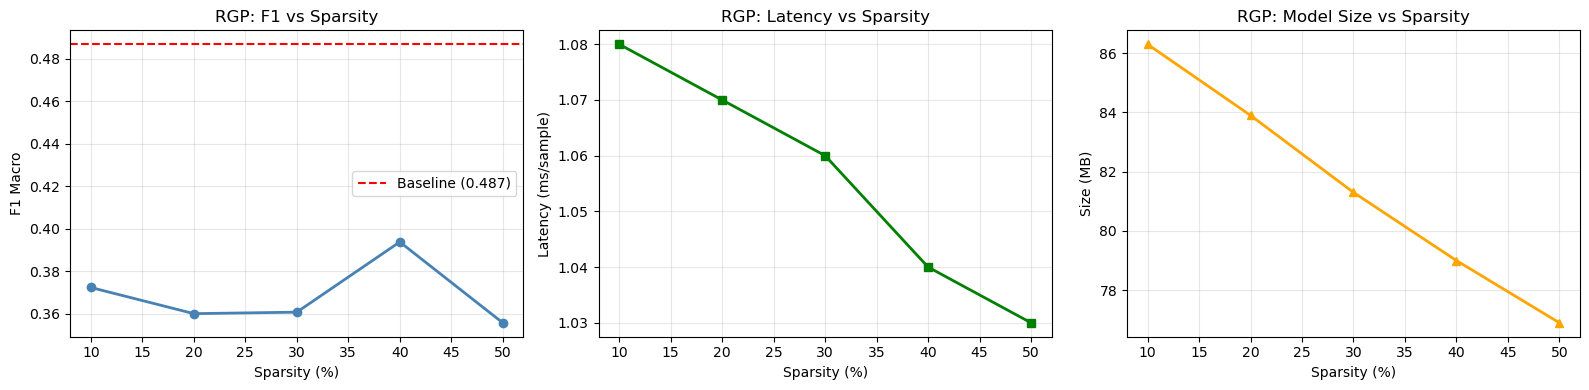

Saved → rgp_checkpoints/rgp_results.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sparsities = [float(m['Sparsity'].strip('%')) for m in rgp_step_metrics]
f1s        = [m['F1 Score'] for m in rgp_step_metrics]
latencies  = [m['Latency (ms)'] for m in rgp_step_metrics]
sizes      = [m['Size (MB)'] for m in rgp_step_metrics]

axes[0].plot(sparsities, f1s, 'o-', color='steelblue', lw=2)
axes[0].axhline(BASELINE_F1, color='red', linestyle='--', label=f'Baseline ({BASELINE_F1:.3f})')
axes[0].set_xlabel('Sparsity (%)'); axes[0].set_ylabel('F1 Macro')
axes[0].set_title('RGP: F1 vs Sparsity'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sparsities, latencies, 's-', color='green', lw=2)
axes[1].set_xlabel('Sparsity (%)'); axes[1].set_ylabel('Latency (ms/sample)')
axes[1].set_title('RGP: Latency vs Sparsity'); axes[1].grid(True, alpha=0.3)

axes[2].plot(sparsities, sizes, '^-', color='orange', lw=2)
axes[2].set_xlabel('Sparsity (%)'); axes[2].set_ylabel('Size (MB)')
axes[2].set_title('RGP: Model Size vs Sparsity'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('rgp_checkpoints', exist_ok=True)
plt.savefig('rgp_checkpoints/rgp_results.png', dpi=150)
plt.show()
print('Saved → rgp_checkpoints/rgp_results.png')
